In [ ]:
!pip install yfinance scikit-learn keras tensorflow gradio

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Fixed ticker
df = yf.download("TCS.NS", start="2018-01-01", end="2024-12-31")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nNull values:")
print(df.isnull().sum())

[*********************100%***********************]  1 of 1 completed

Shape: (1726, 5)

First 5 rows:
Price             Close         High          Low         Open   Volume
Ticker           TCS.NS       TCS.NS       TCS.NS       TCS.NS   TCS.NS
Date                                                                   
2018-01-01  1083.771851  1103.926644  1079.429513  1098.806010  1351760
2018-01-02  1077.872437  1093.603077  1073.366281  1089.670392  1920290
2018-01-03  1080.924316  1093.357250  1077.872440  1078.200180  1257120
2018-01-04  1088.483032  1090.490281  1081.477964  1085.574472   913082
2018-01-05  1101.632080  1105.851500  1085.573801  1085.573801  1153706

Null values:
Price   Ticker
Close   TCS.NS    0
High    TCS.NS    0
Low     TCS.NS    0
Open    TCS.NS    0
Volume  TCS.NS    0
dtype: int64


In [ ]:
# Step 1 — Flatten columns
df.columns = ['Close', 'High', 'Low', 'Open', 'Volume']

In [ ]:
df = df.reset_index()

In [ ]:
df = df.sort_values('Date').reset_index(drop=True)

In [ ]:
print("Columns:", df.columns.tolist())

Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


In [ ]:
print("Shape:", df.shape)

Shape: (1726, 6)


In [ ]:
print(df.head())

        Date        Close         High          Low         Open   Volume
0 2018-01-01  1083.771851  1103.926644  1079.429513  1098.806010  1351760
1 2018-01-02  1077.872437  1093.603077  1073.366281  1089.670392  1920290
2 2018-01-03  1080.924316  1093.357250  1077.872440  1078.200180  1257120
3 2018-01-04  1088.483032  1090.490281  1081.477964  1085.574472   913082
4 2018-01-05  1101.632080  1105.851500  1085.573801  1085.573801  1153706


**feature engineering**

In [ ]:
# Step 2 — Feature Engineering
# Moving Averages
df['MA7']  = df['Close'].rolling(window=7).mean()

In [ ]:
df['MA7']

,MA7
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1721,4090.204276
1722,4050.286586
1723,4016.917864
1724,3994.728620


In [ ]:
df['MA21'] = df['Close'].rolling(window=21).mean()

In [ ]:
df['MA21']

,MA21
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1721,4126.119815
1722,4119.991153
1723,4111.692999
1724,4104.113525


In [ ]:
df['MA50'] = df['Close'].rolling(window=50).mean()

In [ ]:
df['MA50']

,MA50
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1721,3984.153696
1722,3984.920547
1723,3985.727637
1724,3986.829941


In [ ]:
# Price momentum
df['Daily_Return'] = df['Close'].pct_change()

In [ ]:
df['Daily_Return']

,Daily_Return
0,NaN
1,-0.005443
2,0.002831
3,0.006993
4,0.012080
...,...
1721,-0.002878
1722,0.005098
1723,-0.002488
1724,-0.001019


In [ ]:
# Volatility
df['Volatility'] = df['Close'].rolling(window=7).std()

In [ ]:
df['Volatility']

,Volatility
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1721,112.090898
1722,95.801281
1723,77.763586
1724,69.005725


In [ ]:
# Price Range
df['Price_Range'] = df['High'] - df['Low']

In [ ]:
df['Price_Range']

,Price_Range
0,24.497130
1,20.236796
2,15.484810
3,9.012316
4,20.277699
...,...
1721,96.906338
1722,56.663293
1723,53.910903
1724,31.985892


In [ ]:
# Volume trend
df['Volume_MA7'] = df['Volume'].rolling(window=7).mean()

In [ ]:
df['Volume_MA7']

,Volume_MA7
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1721,2.534542e+06
1722,2.422376e+06
1723,2.359839e+06
1724,2.021706e+06


In [ ]:
# RSI (Relative Strength Index)
delta = df['Close'].diff()

In [ ]:
delta

,Close
0,NaN
1,-5.899414
2,3.051880
3,7.558716
4,13.149048
...,...
1721,-11.389893
1722,20.122070
1723,-9.871094
1724,-4.033691


In [ ]:
gain = delta.where(delta > 0, 0).rolling(window=14).mean()

In [ ]:
gain

,Close
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1721,15.847133
1722,13.782785
1723,6.349121
1724,6.349121


In [ ]:
loss = -delta.where(delta < 0, 0).rolling(window=14).mean()

In [ ]:
loss

,Close
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1721,25.640137
1722,25.640137
1723,26.345215
1724,25.375767


In [ ]:
rs = gain / loss

In [ ]:
rs

,Close
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1721,0.618060
1722,0.537547
1723,0.240997
1724,0.250204


In [ ]:
df['RSI'] = 100 - (100 / (1 + rs))

In [ ]:
df['RSI']

,RSI
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1721,38.197580
1722,34.961348
1723,19.419636
1724,20.013060


In [ ]:
# Drop NaN rows created by rolling windows
df = df.dropna().reset_index(drop=True)

In [ ]:
df

,Date,Close,High,Low,Open,Volume,MA7,MA21,MA50,Daily_Return,Volatility,Price_Range,Volume_MA7,RSI
0,2018-03-14,1185.424194,1200.268235,1180.558385,1187.908477,3668668,1228.002703,1231.111770,1211.804370,0.000035,29.738121,19.709849,1.449657e+07,33.876424
1,2018-03-15,1178.361572,1191.850541,1172.571864,1188.750326,2348906,1217.848615,1229.203358,1213.696165,-0.005958,33.138781,19.278677,1.455973e+07,31.626715
2,2018-03-16,1160.294067,1179.305878,1151.794216,1177.991908,7197482,1206.013916,1227.519793,1215.344597,-0.015333,37.152114,27.511662,1.531397e+07,25.461176
3,2018-03-19,1162.470337,1169.450908,1157.953497,1161.649093,3489940,1195.868600,1225.665138,1216.975518,0.001876,38.084179,11.497411,1.553370e+07,28.685259
4,2018-03-20,1176.370239,1179.798872,1157.543184,1157.953806,4024984,1185.940360,1224.331613,1218.733262,0.011957,31.338721,22.255688,1.584121e+07,32.034465
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1672,2024-12-23,3946.770020,4002.484177,3905.577840,3986.396226,2195338,4090.204276,4126.119815,3984.153696,-0.002878,112.090898,96.906338,2.534542e+06,38.197580
1673,2024-12-24,3966.892090,4003.433625,3946.770332,3946.770332,1181886,4050.286586,4119.991153,3984.920547,0.005098,95.801281,56.663293,2.422376e+06,34.961348
1674,2024-12-26,3957.020996,3986.301772,3932.390868,3966.891863,1208464,4016.917864,4111.692999,3985.727637,-0.002488,77.763586,53.910903,2.359839e+06,19.419636
1675,2024-12-27,3952.987305,3968.268402,3936.282511,3951.231320,858100,3994.728620,4104.113525,3986.829941,-0.001019,69.005725,31.985892,2.021706e+06,20.013060


In [ ]:
print("Shape after feature engineering:", df.shape)

Shape after feature engineering: (1677, 14)


In [ ]:
print("\nAll features:")
print(df.columns.tolist())


All features:
['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'MA7', 'MA21', 'MA50', 'Daily_Return', 'Volatility', 'Price_Range', 'Volume_MA7', 'RSI']


In [ ]:
print("\nSample:")
print(df.tail())


Sample:
           Date        Close         High          Low         Open   Volume  \
1672 2024-12-23  3946.770020  4002.484177  3905.577840  3986.396226  2195338   
1673 2024-12-24  3966.892090  4003.433625  3946.770332  3946.770332  1181886   
1674 2024-12-26  3957.020996  3986.301772  3932.390868  3966.891863  1208464   
1675 2024-12-27  3952.987305  3968.268402  3936.282511  3951.231320   858100   
1676 2024-12-30  3947.244629  3985.684423  3902.825497  3939.841595  1527169   

              MA7         MA21         MA50  Daily_Return  Volatility  \
1672  4090.204276  4126.119815  3984.153696     -0.002878  112.090898   
1673  4050.286586  4119.991153  3984.920547      0.005098   95.801281   
1674  4016.917864  4111.692999  3985.727637     -0.002488   77.763586   
1675  3994.728620  4104.113525  3986.829941     -0.001019   69.005725   
1676  3969.095180  4100.222075  3988.231147     -0.001453   38.329994   

      Price_Range    Volume_MA7        RSI  
1672    96.906338  2.53454

**Visualization**

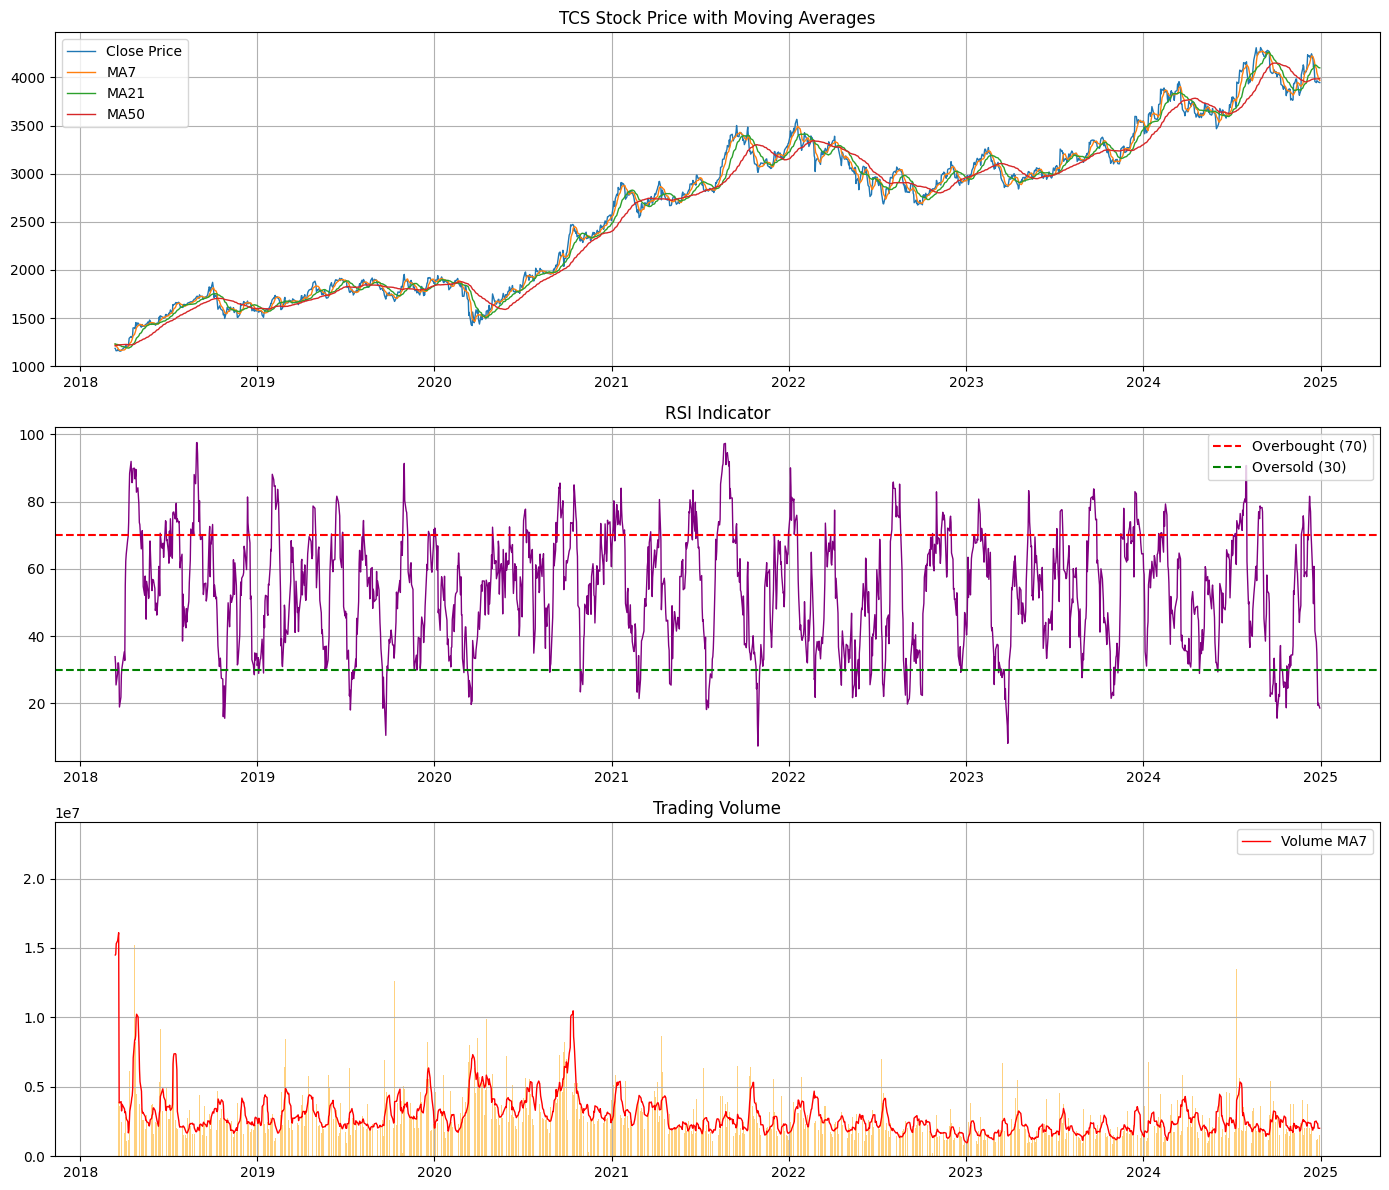

Charts saved!


In [ ]:
# Step 3 — Visualize
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
# Plot 1 — Close price with MAs
axes[0].plot(df['Date'], df['Close'], label='Close Price', linewidth=1)
axes[0].plot(df['Date'], df['MA7'], label='MA7', linewidth=1)
axes[0].plot(df['Date'], df['MA21'], label='MA21', linewidth=1)
axes[0].plot(df['Date'], df['MA50'], label='MA50', linewidth=1)
axes[0].set_title('TCS Stock Price with Moving Averages')
axes[0].legend()
axes[0].grid(True)

# Plot 2 — RSI
axes[1].plot(df['Date'], df['RSI'], color='purple', linewidth=1)
axes[1].axhline(70, color='red', linestyle='--', label='Overbought (70)')
axes[1].axhline(30, color='green', linestyle='--', label='Oversold (30)')
axes[1].set_title('RSI Indicator')
axes[1].legend()
axes[1].grid(True)

# Plot 3 — Volume
axes[2].bar(df['Date'], df['Volume'], color='orange', alpha=0.5)
axes[2].plot(df['Date'], df['Volume_MA7'], color='red', linewidth=1, label='Volume MA7')
axes[2].set_title('Trading Volume')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved!")

**LSTM**

In [ ]:
# Step 4 — Prepare data for LSTM
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# Use these features for model input
feature_cols = ['Close', 'MA7', 'MA21', 'MA50', 'RSI',
                'Volatility', 'Price_Range', 'Daily_Return', 'Volume_MA7']

In [ ]:
feature_cols

['Close',
 'MA7',
 'MA21',
 'MA50',
 'RSI',
 'Volatility',
 'Price_Range',
 'Daily_Return',
 'Volume_MA7']

In [ ]:
# Scale data
scaler = MinMaxScaler()

In [ ]:
scaler

MinMaxScaler()

In [ ]:
scaled = scaler.fit_transform(df[feature_cols])

In [ ]:
scaled

array([[0.00909779, 0.02054219, 0.01404305, ..., 0.04701456, 0.48889273,
        0.89399963],
       [0.00685914, 0.01727799, 0.01342247, ..., 0.04537873, 0.4577706 ,
        0.89817345],
       [0.00113227, 0.01347353, 0.01287499, ..., 0.07661404, 0.40908378,
        0.94801392],
       ...,
       [0.88761338, 0.91708592, 0.95076703, ..., 0.17677072, 0.475789  ,
        0.09200464],
       [0.88633482, 0.90995281, 0.9483023 , ..., 0.09358892, 0.48341799,
        0.06966084],
       [0.88451455, 0.90171251, 0.94703685, ..., 0.28659729, 0.48116736,
        0.06920551]])

In [ ]:
# Separate scaler for Close only (needed for inverse transform later)
close_scaler = MinMaxScaler()

In [ ]:
close_scaler

MinMaxScaler()

In [ ]:
close_scaled = close_scaler.fit_transform(df[['Close']])

In [ ]:
close_scaled

array([[0.00909779],
       [0.00685914],
       [0.00113227],
       ...,
       [0.88761338],
       [0.88633482],
       [0.88451455]])

In [ ]:
# Create sequences — 60 days lookback
SEQ_LEN = 60

In [ ]:
SEQ_LEN

60

In [ ]:
X, y = [], []
for i in range(SEQ_LEN, len(scaled)):
    X.append(scaled[i-SEQ_LEN:i])        # 60 days of all features
    y.append(close_scaled[i, 0])          # next day Close price

In [ ]:
X, y = np.array(X), np.array(y)

# Train/test split — 80/20
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1293, 60, 9)
X_test shape: (324, 60, 9)
y_train shape: (1293,)
y_test shape: (324,)


**Build LSTM**

In [ ]:
# Step 5 — Build LSTM Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(SEQ_LEN, len(feature_cols))),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

In [ ]:
model

<Sequential name=sequential, built=True>

In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,025 (519.63 KB)

 Trainable params: 133,025 (519.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 6 — Train
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
early_stop

In [ ]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001)

In [ ]:
reduce_lr

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.0224 - val_loss: 0.0010 - learning_rate: 0.0010
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0043 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0034 - val_loss: 5.4432e-04 - learning_rate: 0.0010
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0029 - val_loss: 9.4206e-04 - learning_rate: 0.0010
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0031 - val_loss: 0.0032 - learning_rate: 0.0010
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0026 - val_loss: 0.0010 - learning_rate: 0.0010
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0026 - val_loss: 4.9428e-04 - learning_rate: 0.0010
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0025 - val_loss: 9.5923e-04 - learning_rate: 0.0010
Epoch 9/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0020 - val_loss: 4.7167e-04 - learning_rat

In [ ]:
history

In [ ]:
print("Training done!")
print("Best val_loss:", min(history.history['val_loss']))

Training done!
Best val_loss: 0.0003924620687030256


**Evalution**

In [ ]:
# Step 7 — Evaluate on test data
y_pred = model.predict(X_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


In [ ]:
y_pred

array([[0.6139548 ],
       [0.6123123 ],
       [0.61191314],
       [0.61274475],
       [0.6159211 ],
       [0.62023336],
       [0.6260237 ],
       [0.63349676],
       [0.64171356],
       [0.6500688 ],
       [0.6585491 ],
       [0.66675675],
       [0.674345  ],
       [0.6812301 ],
       [0.6873396 ],
       [0.69184643],
       [0.69500405],
       [0.6970898 ],
       [0.6972422 ],
       [0.6960948 ],
       [0.6936122 ],
       [0.68944395],
       [0.6852036 ],
       [0.6818116 ],
       [0.6792796 ],
       [0.67734957],
       [0.6757035 ],
       [0.6736538 ],
       [0.67167413],
       [0.6694286 ],
       [0.66689456],
       [0.66399777],
       [0.6610615 ],
       [0.6588442 ],
       [0.6562943 ],
       [0.6531739 ],
       [0.6486519 ],
       [0.64303267],
       [0.6369111 ],
       [0.6305329 ],
       [0.62398773],
       [0.6182677 ],
       [0.6130459 ],
       [0.60901487],
       [0.6060638 ],
       [0.6043416 ],
       [0.60338277],
       [0.602

In [ ]:
# Inverse transform to get actual prices
y_pred_actual = close_scaler.inverse_transform(y_pred)

In [ ]:
y_pred_actual

array([[3093.6655],
       [3088.484 ],
       [3087.2244],
       [3089.8481],
       [3099.869 ],
       [3113.4736],
       [3131.7415],
       [3155.3179],
       [3181.2405],
       [3207.6003],
       [3234.3545],
       [3260.2485],
       [3284.1885],
       [3305.91  ],
       [3325.1846],
       [3339.4028],
       [3349.3647],
       [3355.945 ],
       [3356.4258],
       [3352.806 ],
       [3344.9739],
       [3331.8235],
       [3318.4458],
       [3307.7444],
       [3299.7563],
       [3293.6675],
       [3288.4744],
       [3282.0076],
       [3275.7622],
       [3268.6777],
       [3260.6833],
       [3251.5444],
       [3242.281 ],
       [3235.2852],
       [3227.2407],
       [3217.3965],
       [3203.1301],
       [3185.4023],
       [3166.0894],
       [3145.9673],
       [3125.318 ],
       [3107.2722],
       [3090.798 ],
       [3078.0808],
       [3068.7705],
       [3063.3374],
       [3060.3123],
       [3057.4841],
       [3056.1438],
       [3060.1165],


In [ ]:
y_test_actual = close_scaler.inverse_transform(y_test.reshape(-1, 1))

In [ ]:
y_test_actual

array([[3175.50952148],
       [3185.58813477],
       [3186.09838867],
       [3209.64746094],
       [3197.24633789],
       [3233.24145508],
       [3326.27270508],
       [3314.24316406],
       [3306.99780273],
       [3342.52905273],
       [3349.82104492],
       [3349.72802734],
       [3330.453125  ],
       [3347.49853516],
       [3322.88232422],
       [3330.82421875],
       [3334.16870117],
       [3285.35351562],
       [3277.78393555],
       [3264.08203125],
       [3286.2824707 ],
       [3334.21508789],
       [3363.98681641],
       [3379.73217773],
       [3370.95361328],
       [3353.30419922],
       [3290.7421875 ],
       [3317.02978516],
       [3273.55712891],
       [3257.76513672],
       [3239.37231445],
       [3218.32397461],
       [3254.55322266],
       [3175.94897461],
       [3157.27612305],
       [3107.59033203],
       [3120.81494141],
       [3146.51953125],
       [3137.39257812],
       [3101.90917969],
       [3129.33691406],
       [3120.768

In [ ]:
# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

In [ ]:
rmse

np.float64(265.4488957853594)

In [ ]:
mae = mean_absolute_error(y_test_actual, y_pred_actual)

In [ ]:
mae

224.61501434702933

In [ ]:
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

In [ ]:
mape

np.float64(5.788305729572088)

In [ ]:
print(f"RMSE: ₹{rmse:.2f}")
print(f"MAE:  ₹{mae:.2f}")
print(f"MAPE: {mape:.2f}%")

RMSE: ₹265.45
MAE:  ₹224.62
MAPE: 5.79%


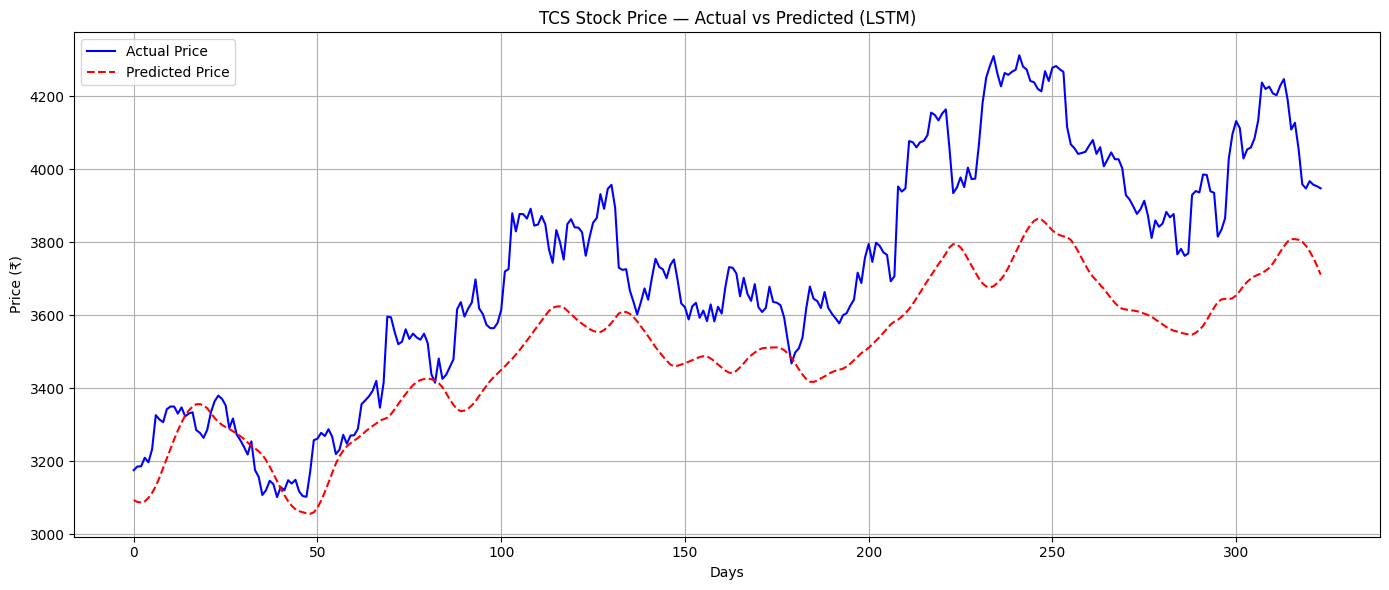

Chart saved!


In [ ]:
# Step 8 — Plot predictions vs actual
plt.figure(figsize=(14, 6))
plt.plot(y_test_actual, label='Actual Price', color='blue', linewidth=1.5)
plt.plot(y_pred_actual, label='Predicted Price', color='red', linewidth=1.5, linestyle='--')
plt.title('TCS Stock Price — Actual vs Predicted (LSTM)')
plt.xlabel('Days')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('prediction_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

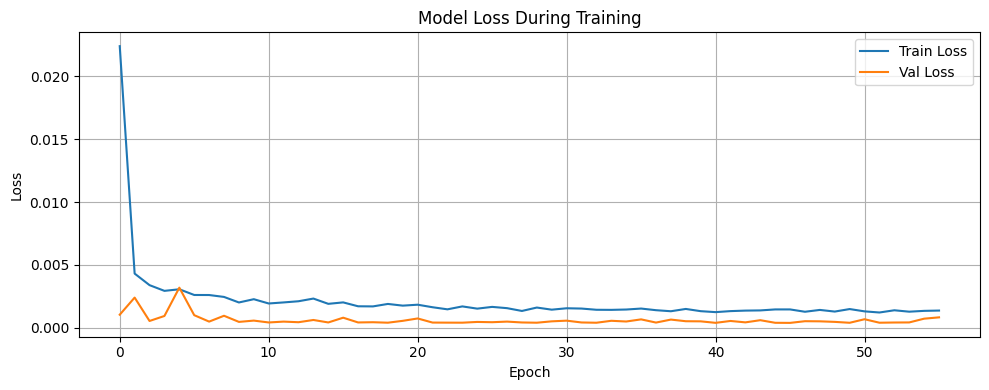

In [ ]:
# Step 9 — Training loss curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import joblib

In [ ]:
# 1. Save the trained LSTM model using the modern .keras extension
model.save('stock_model.keras')

# 2. Save the scaler (keep this as .gz)
joblib.dump(scaler, 'scaler.gz')

print("Files saved: stock_model.keras and scaler.gz")

Files saved: stock_model.keras and scaler.gz


In [89]:
from google.colab import files

# Download the model file
files.download('stock_model.keras')

# Download the scaler file
files.download('scaler.gz')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [87]:
import os
print(os.listdir())

['.config', 'stock_model.keras', 'loss_curve.png', 'eda_charts.png', 'scaler.gz', 'stock_model.h5', 'prediction_chart.png', 'sample_data']
